<a href="https://colab.research.google.com/github/Itzelsosa/c-/blob/main/propulsion_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# problem 2.2
def rocket_efficiencies(F, mdot, u, Q_R, eta_comb=1.0, g0=9.80665):
    """
    Inputs:
      F        thrust [N]
      mdot     propellant mass flow rate [kg/s]
      u        vehicle speed [m/s]
      Q_R      chemical energy content of propellant [J/kg]
      eta_comb combustion efficiency (0 to 1)
      g0       standard gravity [m/s^2]

    Returns a dictionary of key performance metrics.
    """

    # 1) Effective exhaust velocity
    c = F / mdot

    # 2) Jet kinetic energy per unit propellant mass (rocket frame)
    jet_ke_per_kg = 0.5 * c**2  # [J/kg]

    # 3) Chemical power input
    P_chem = mdot * Q_R  # [W] because (kg/s)*(J/kg) = J/s

    # 4) Jet kinetic power (rocket frame)
    P_jet = mdot * jet_ke_per_kg  # = 0.5*mdot*c^2

    # 5) Internal efficiency (how well chemical -> jet kinetic)
    # If eta_comb = 1, it's just P_jet / P_chem
    eta_int = P_jet / (eta_comb * P_chem)

    # 6) Useful vehicle power
    P_vehicle = F * u

    # 7) Residual jet power in the ground frame (book form)
    # (this is the "wasted" kinetic energy rate in the exhaust)
    P_residual = 0.5 * mdot * (c - u)**2

    # 8) Propulsive efficiency (book equation)
    eta_p = P_vehicle / (P_vehicle + P_residual)

    # 9) Overall efficiency (useful / chemical)
    eta_o = P_vehicle / (eta_comb * P_chem)

    # 10) Specific impulse
    Isp = F / (mdot * g0)  # [s]

    # 11) Specific propellant consumption (in 1/s)
    SPC = (mdot * g0) / F  # = 1/Isp

    return {
        "c (m/s)": c,
        "jet KE per kg (J/kg)": jet_ke_per_kg,
        "jet KE per kg (MJ/kg)": jet_ke_per_kg / 1e6,
        "P_chem (W)": P_chem,
        "P_jet (W)": P_jet,
        "P_vehicle (W)": P_vehicle,
        "P_residual (W)": P_residual,
        "eta_int": eta_int,
        "eta_p": eta_p,
        "eta_o": eta_o,
        "Isp (s)": Isp,
        "SPC (1/s)": SPC,
    }


# ---- Try it with the book's example numbers ----
F = 8896
mdot = 3.867
u = 400
Q_R = 6.911e6  # J/kg
results = rocket_efficiencies(F, mdot, u, Q_R, eta_comb=1.0)

for k, v in results.items():
    print(f"{k:22s} = {v}")


c (m/s)                = 2300.4913369537107
jet KE per kg (J/kg)   = 2646130.195699536
jet KE per kg (MJ/kg)  = 2.6461301956995356
P_chem (W)             = 26724837.0
P_jet (W)              = 10232585.466770105
P_vehicle (W)          = 3558400
P_residual (W)         = 6983545.466770105
eta_int                = 0.3828867306756672
eta_p                  = 0.33754680397623427
eta_o                  = 0.13314954923766234
Isp (s)                = 234.58483141069692
SPC (1/s)              = 0.0042628502191996405


specific_imp           = 217.39130434782606
total_imp              = 3956521.739130434
m_prop_required        = 18200
v_propellant           = 315.31531531531533


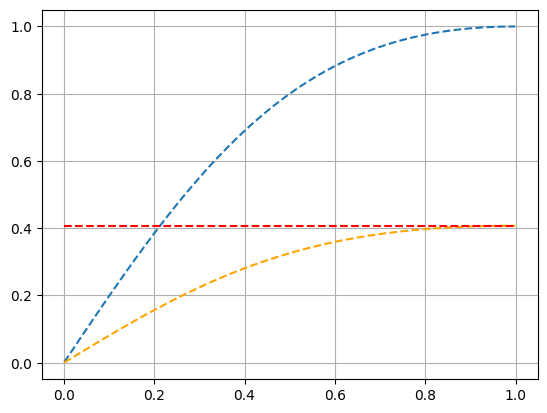

In [ ]:
from re import T
import numpy as np
# Problem 2.3
"""
 A certain rocket engine (flying horizontally) has an effective exhaust velocity of
7000 ft/sec; it consumes 280 lbm/sec of propellant mass, and liberates 2400 Btu/lbm.
The unit operates for 65 sec. Construct a set of curves plotting the propulsive, internal,
and overall efficiencies versus the velocity ratio u∕c (0 < u∕c < 1.0). The rated flight
velocity equals 5000 ft/sec. Calculate (a) the specific impulse; (b) the total impulse;
(c) the mass of propellants required; (d) the volume that the propellants occupy if their
average specific gravity is 0.925. Neglect gravity and drag.
  """
#given
c = 7000     # ft/sec
mdot  = 280  # [lbm/sec]
qr = 2400    # [Btu/lbm]
tb = 65      # [sec]
u = 5000     # [ft/sec]
go = 32.2


def sol(c, mdot, qr, tb, u, go = 32.2, sg = 0.925 ):
  """
  Inputs:
  c        effective exhaust velocity [ft/sec]
  mdot     propellant mass flow rate [lbm/sec]
  qr       heat of reaction per unit propellant [Btu/lbm]
  tb       burning time [sec]
  u        Rated flight speed [ft/sec]
  """
  # (a) the specific impulse

  Is = c/go

  # (b) the total impulse

  F = (mdot*c)/ go
  It = F*tb

  # (c) the mass of propellants required

  mp = mdot*tb

  #(d) the volume that the propellants occupy.
  #since is sg = 0.925 specific gravity therefore is water
  ρ_water = 62.4 # [lbm/ft^3]
  ρ_propellant = 0.925*62.4
  v = mp/ρ_propellant

  return{
      "specific_imp" : Is,
      "total_imp  ": It,
      "m_prop_required" : mp,
      "v_propellant" : v
  }

results = sol(c, mdot, qr, tb, u, go = 32.2)
for k, v in results.items():
      print(f"{k:22s} = {v}")

#plot

import matplotlib.pyplot as plt
%matplotlib inline
# for velocity ratio u∕c (0 < u∕c < 1.0)
r = np.linspace(0.001, 0.999, 400)
#internal efficiency
int_ef = c**2/(2*go) /(qr*778.169)
#propulsive efficiency
pro_ef = 2*r / (1 + (r**2))
#overal efficiency
npo = int_ef* pro_ef
fig = plt.figure()
plt.plot(r,pro_ef, '--')
plt.plot(r,npo, linestyle = 'dashed' , color = 'orange' )
plt.plot(r,int_ef*np.ones_like(r), linestyle = 'dashed' , color = 'red' )
plt.grid()
plt.show()



In [ ]:
#problem 3.5
"""
A Russian rocket engine (RD-110 with LOX-kerosene) consists of four thrust chambers
supplied by a single turbopump. The exhaust from the turbine of the turbopump then is
ducted to four vernier nozzles (which can be rotated to provide some control of the flight
path). Using the information below, determine the thrust and mass flow rate of the four
vernier gas nozzles. For individual thrust chambers (vacuum):
F =73.14kN,c = 2857m∕sec
For overall engine with verniers (vacuum):
F =297.93kN,c = 2845m∕sec
"""
#Given
F_individual = 73140 #  kN
c_individual =  2857 #  m∕sec
F_overall = 297930  # kN
c_overall = 2845  # m∕sec
chambers = 4
nozzles = 4


# Thrust of one nozzle

F = F_overall - F_individual*4
print("the individual nozzle thrust is " + str(F))

# mass flow of the nozzle

m_individual = F_individual/c_individual
m_overall = F_overall/c_overall
mdot =  m_overall - m_individual*4

print("the individual nozzle mass flow  is " + str(mdot))



the individual nozzle thrust is 5370
the individual nozzle mass flow  is 2.319442334155383


c = 8043.5 ft/s
u boundaries for eta_p = 0.8: [4021.75000000000, 16087.0000000000] ft/s
So eta_p >= 0.8 when u is between these two values.


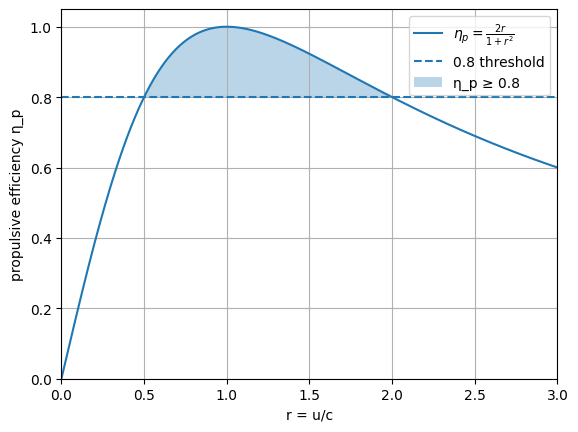

In [ ]:
import sympy as sy

# Problem 2.6
Is = 250                       # sec
g0 = 32.174                    # ft/s^2  (use English units!)
c_val = Is * g0                # ft/s

# Symbols
eta, u, c = sy.symbols('eta u c', positive=True, real=True)

# Propulsive efficiency equation
eta_expr = (2*(u/c)) / (1 + (u/c)**2)

# Solve eta_p = 0.8 for u (gives the two boundary speeds)
#solve u
sol_u = sy.solve(sy.Eq(eta_expr, sy.Rational(4,5)), u)  # 0.8 = 4/5 exactly


sol_u = [sy.N(s.subs(c, c_val)) for s in sol_u]         # plug in c and convert to numbers

sol_u_sorted = sorted(sol_u)

print("c =", c_val, "ft/s")
print("u boundaries for eta_p = 0.8:", sol_u_sorted, "ft/s")
print("So eta_p >= 0.8 when u is between these two values.")

import numpy as np
import matplotlib.pyplot as plt

# r = u/c from 0 to 1
r = np.linspace(0.0, 3.0, 400)
eta_p = 2*r/(1 + r**2)

plt.figure()
plt.plot(r, eta_p, label=r"$\eta_p = \frac{2r}{1+r^2}$")
plt.axhline(0.8, linestyle="--", label="0.8 threshold")
plt.ylim(0.0, 1.05)
plt.xlim(0.0, 3.0)
plt.xlabel("r = u/c")
plt.ylabel("propulsive efficiency η_p")
plt.grid(True)

# shade region where eta_p >= 0.8
mask = eta_p >= 0.8
plt.fill_between(r, eta_p, 0.8, where=mask, alpha=0.3, label="η_p ≥ 0.8")

plt.legend()
plt.show()

